In [150]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt


In [151]:
import os
os.getcwd()

'd:\\INTERNSHIP\\credit card fraud detection\\notebooks'

In [152]:
dataset = pd.read_csv("../data/raw/fraud data.csv")
dataset.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21/06/2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,19/03/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21/06/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",17/01/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,21/06/2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",21/10/1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,21/06/2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,25/07/1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,21/06/2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,06/07/1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [153]:
dataset.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [154]:
dataset.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                   float64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [155]:
# REMOVING UNWANTED COLUMN
dataset=dataset.drop(columns=['Unnamed: 0'])

In [156]:
dataset[['trans_date_trans_time']]

,trans_date_trans_time
0,21/06/2020 12:14
1,21/06/2020 12:14
2,21/06/2020 12:14
3,21/06/2020 12:15
4,21/06/2020 12:15
...,...
555714,31/12/2020 23:59
555715,31/12/2020 23:59
555716,31/12/2020 23:59
555717,31/12/2020 23:59


In [157]:
# First convert string column to datetime
dataset["trans_date_trans_time"] = pd.to_datetime(
    dataset["trans_date_trans_time"],
    dayfirst=True
)

# Extract information from trans_date_trans_time
dataset["day_of_week"] = dataset["trans_date_trans_time"].dt.dayofweek
dataset["date"] = dataset["trans_date_trans_time"].dt.date
dataset["day"] = dataset["trans_date_trans_time"].dt.day
dataset["month"] = dataset["trans_date_trans_time"].dt.month
dataset["hour"] = dataset["trans_date_trans_time"].dt.hour
dataset["minute"] = dataset["trans_date_trans_time"].dt.minute
dataset["year"] = dataset["trans_date_trans_time"].dt.year

# Create weekend feature
dataset["weekend"] = dataset["day_of_week"].isin([5, 6]).astype(int)

# Create night feature
dataset["night"] = dataset["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)

In [158]:
dataset["dob"] = pd.to_datetime(dataset["dob"], dayfirst=True)

dataset["age"] = dataset["trans_date_trans_time"].dt.year - dataset["dob"].dt.year

In [159]:
#creating age group on the basis of the age 
dataset['age_group']=pd.cut(dataset['age'], bins=[0, 25, 40, 60, 100],
    labels=["0-25", "26-40", "41-60", "60+"])

In [160]:
#dropping the unix_time
dataset=dataset.drop(columns=['unix_time'])

In [161]:
#cc_num and trans_num are sensitive values,and other useless features has been removed
drop_cols = [
    "cc_num",
    "trans_num",
    "first",
    "last",
    "street",
    "dob",
    "trans_date_trans_time",
    
]

dataset = dataset.drop(columns=drop_cols)

In [162]:
dataset.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud',
       'day_of_week', 'date', 'day', 'month', 'hour', 'minute', 'year',
       'weekend', 'night', 'age', 'age_group'],
      dtype='str')

In [163]:
#checking duplicate
dataset.duplicated().sum()

np.int64(0)

In [164]:
#checking the null values
dataset.isnull().sum()


merchant       0
category       0
amt            0
gender         0
city           0
state          0
zip            0
lat            0
long           0
city_pop       0
job            0
merch_lat      0
merch_long     0
is_fraud       0
day_of_week    0
date           0
day            0
month          0
hour           0
minute         0
year           0
weekend        0
night          0
age            0
age_group      0
dtype: int64

In [165]:
dataset.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud',
       'day_of_week', 'date', 'day', 'month', 'hour', 'minute', 'year',
       'weekend', 'night', 'age', 'age_group'],
      dtype='str')

In [166]:
# Percentage of fraud and not fraud
total = len(dataset)

notfraud = (dataset["is_fraud"] == 0).sum()
isfraud = (dataset["is_fraud"] == 1).sum()

notfraud_percentage = (notfraud / total) * 100
isfraud_percentage = (isfraud / total) * 100

print("Not fraud percentage:", round(notfraud_percentage, 2), "%")
print("Fraud percentage:", round(isfraud_percentage, 2), "%")
#HIGHLY IMBALANCE DATASET

Not fraud percentage: 99.61 %
Fraud percentage: 0.39 %


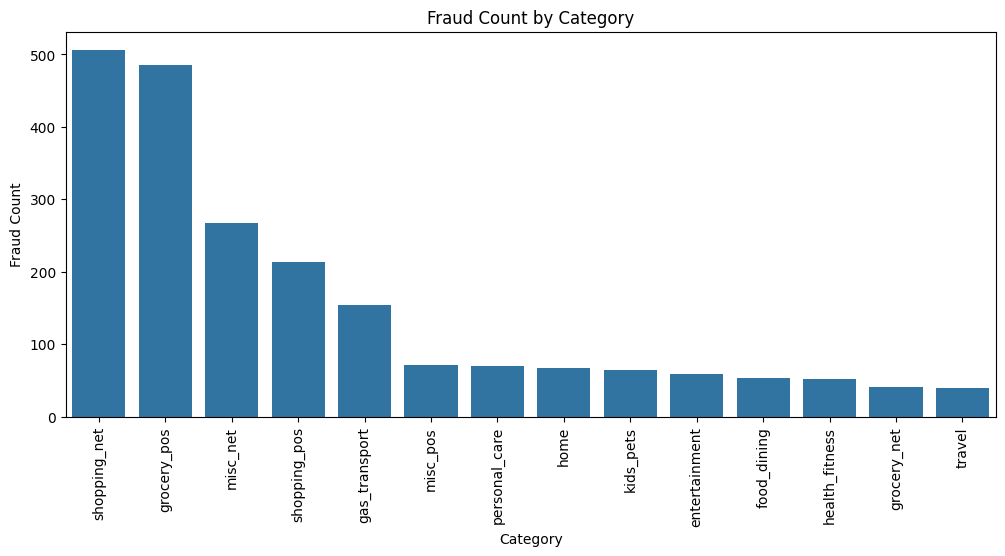

In [167]:
fraud_count_by_category = dataset[dataset["is_fraud"] == 1]["category"].value_counts()

fraud_count_by_category

plt.figure(figsize=(12, 5))
sns.barplot(
    x=fraud_count_by_category.index,
    y=fraud_count_by_category.values
)

plt.xlabel("Category")
plt.ylabel("Fraud Count")
plt.title("Fraud Count by Category")
plt.xticks(rotation=90)
plt.show()

In [168]:
dataset['amt'].value_counts()

amt
1.10       239
1.14       237
1.08       229
1.03       227
1.31       227
          ... 
850.87       1
516.74       1
255.42       1
302.79       1
1164.37      1
Name: count, Length: 37256, dtype: int64

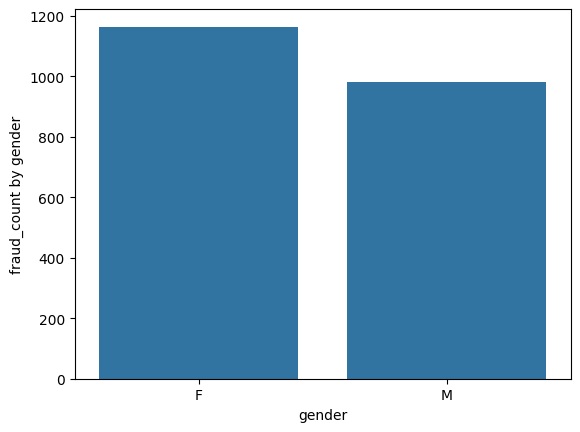

In [169]:
#influence of amt on target variable
fraud_count_by_gender=dataset[dataset['is_fraud']==1]['gender'].value_counts()
sns.barplot(x=fraud_count_by_gender.index,y=fraud_count_by_gender.values)
plt.xlabel('gender')
plt.ylabel('fraud_count by gender')
plt.show()


In [170]:
dataset.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

is_fraud       1.000000
amt            0.182267
night          0.024377
hour           0.011686
day_of_week    0.009365
age            0.007513
lat            0.005863
merch_lat      0.005812
weekend        0.002606
long          -0.000972
merch_long    -0.001060
minute        -0.002028
zip           -0.002271
city_pop      -0.004910
day           -0.009203
month         -0.011748
year                NaN
Name: is_fraud, dtype: float64

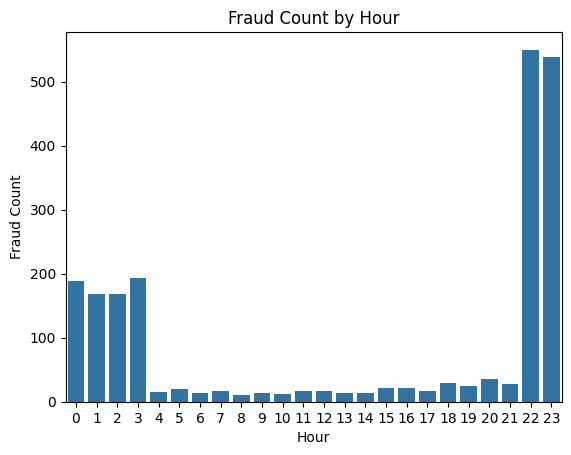

In [171]:
# Analyze fraud count on the basis of hour
fraudcount_byhour = dataset[dataset["is_fraud"] == 1]["hour"].value_counts().sort_index()

sns.barplot(x=fraudcount_byhour.index, y=fraudcount_byhour.values)

plt.xlabel("Hour")
plt.ylabel("Fraud Count")
plt.title("Fraud Count by Hour")
plt.show()

In [172]:
dataset[['night']]

,night
0,0
1,0
2,0
3,0
4,0
...,...
555714,0
555715,0
555716,0
555717,0


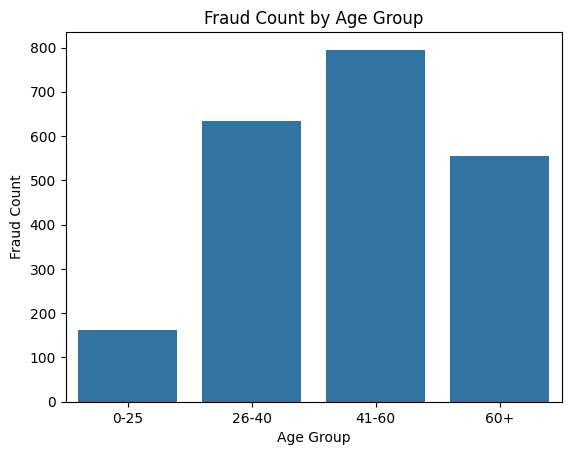

In [173]:
# analyse fraud count on the basis of age group

fraudcount_byage = dataset.groupby('age_group')['is_fraud'].sum()

sns.barplot(x=fraudcount_byage.index, y=fraudcount_byage.values)

plt.xlabel('Age Group')
plt.ylabel('Fraud Count')
plt.title('Fraud Count by Age Group')
plt.show()

In [174]:
dataset.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud',
       'day_of_week', 'date', 'day', 'month', 'hour', 'minute', 'year',
       'weekend', 'night', 'age', 'age_group'],
      dtype='str')

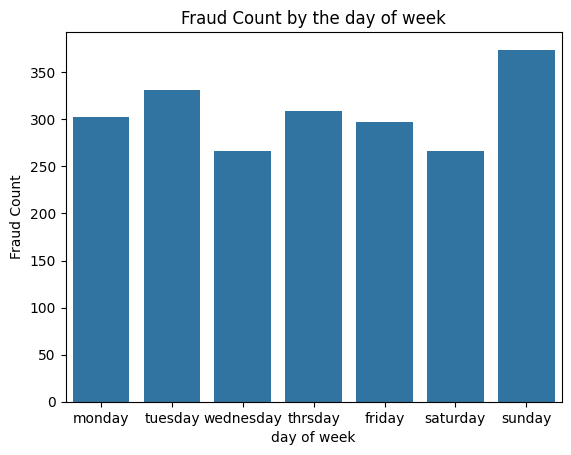

In [175]:
#analyse on the basis of dayofweek

fraudcount_bydayofweek = dataset[dataset["is_fraud"] == 1]["day_of_week"].value_counts().sort_index()

sns.barplot(x=fraudcount_bydayofweek.index, y=fraudcount_bydayofweek.values)


plt.xlabel("day of week")
plt.xticks([0,1,2,3,4,5,6],['monday','tuesday','wednesday','thrsday','friday','saturday','sunday'])
plt.ylabel("Fraud Count")
plt.title("Fraud Count by the day of week")
plt.show()


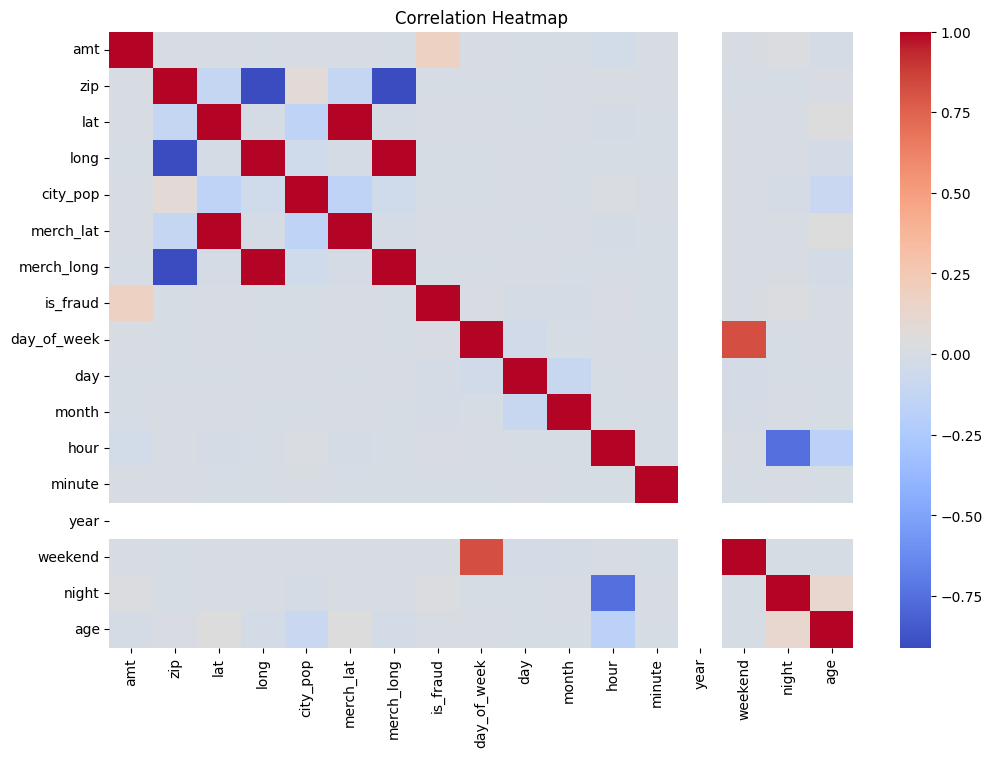

In [176]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    dataset.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [177]:
# check the outlier in dataset
def detectoutoutlier(column):
    q1 = dataset[column].quantile(0.25)
    q3 = dataset[column].quantile(0.75)
    IQR = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = dataset[(dataset[column] < lower) | (dataset[column] > upper)]

    print("column:", column)
    print("lower limit:", lower)
    print("upper limit:", upper)
    print("no of outlier:", outliers.shape[0])
    print("outlier percentage:", round((outliers.shape[0] / len(dataset)) * 100, 2), "%")

    return outliers

In [178]:
amt_outliers = detectoutoutlier("amt")
age_outliers = detectoutoutlier("age")
city_pop_outliers = detectoutoutlier("city_pop")


column: amt
lower limit: -100.44000000000003
upper limit: 193.08000000000004
no of outlier: 27778
outlier percentage: 5.0 %
column: age
lower limit: -4.5
upper limit: 95.5
no of outlier: 199
outlier percentage: 0.04 %
column: city_pop
lower limit: -27675.0
upper limit: 48101.0
no of outlier: 104151
outlier percentage: 18.74 %


In [179]:
amt_outliers["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    94.193246
1     5.806754
Name: proportion, dtype: float64

In [180]:
import pandas as pd
import numpy as np

dataset["log_amt"] = np.log1p(dataset["amt"])

dataset["amount_group"] = pd.cut(
    dataset["amt"],
    bins=[0, 50, 200, 500, dataset["amt"].max()],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)


# now check outlier
log_amt_outliers = detectoutoutlier("log_amt")

column: log_amt
lower limit: -0.7372032781804911
upper limit: 7.5318193099111035
no of outlier: 402
outlier percentage: 0.07 %


In [181]:
dataset[["amt", "amount_group"]].head()

,amt,amount_group
0,2.86,Low
1,29.84,Low
2,41.28,Low
3,60.05,Medium
4,3.19,Low


In [182]:
fraudrate_by_amount_group = dataset.groupby("amount_group")["is_fraud"].mean() * 100

fraudrate_by_amount_group

amount_group
Low           0.159900
Medium        0.029821
High          2.983758
Very High    17.045081
Name: is_fraud, dtype: float64

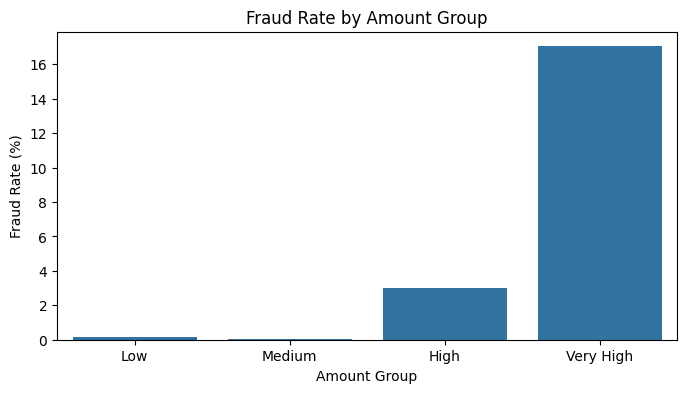

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.barplot(
    x=fraudrate_by_amount_group.index,
    y=fraudrate_by_amount_group.values
)

plt.xlabel("Amount Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Amount Group")
plt.show()

In [184]:
#selecting the numeruc one to detect outlier
outlier_columns = ["amt", "age", "city_pop", "log_amt"]

for col in outlier_columns:
    detectoutoutlier(col)


column: amt
lower limit: -100.44000000000003
upper limit: 193.08000000000004
no of outlier: 27778
outlier percentage: 5.0 %
column: age
lower limit: -4.5
upper limit: 95.5
no of outlier: 199
outlier percentage: 0.04 %
column: city_pop
lower limit: -27675.0
upper limit: 48101.0
no of outlier: 104151
outlier percentage: 18.74 %
column: log_amt
lower limit: -0.7372032781804911
upper limit: 7.5318193099111035
no of outlier: 402
outlier percentage: 0.07 %


In [185]:
#grouping the city population to understand better
dataset['city_pop_group']=pd.cut(dataset['city_pop'],
                                 bins=[0,1000,10000,100000,dataset['city_pop'].max()],
                                 labels=['small','medium','large','very large'],
                                 include_lowest=True
                                 )


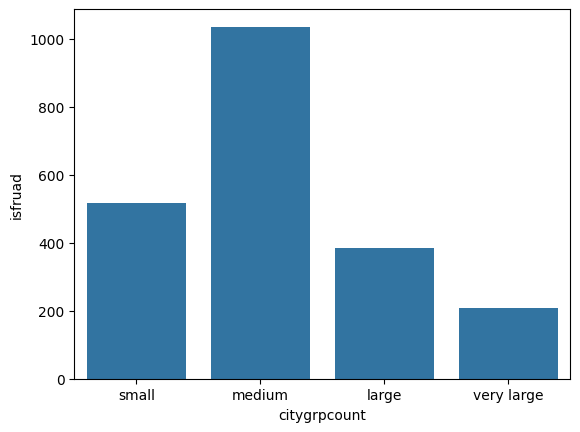

In [186]:
#analyse the fraud on the basis of the city  groupgr
citygrp=dataset.groupby('city_pop_group')['is_fraud'].sum()
sns.barplot(x=citygrp.index,y=citygrp.values)
plt.xlabel('citygrpcount')
plt.ylabel('isfruad')
plt.show()

In [187]:
# Create distance between customer location and merchant location

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

dataset["distance_km"] = haversine_distance(
    dataset["lat"],
    dataset["long"],
    dataset["merch_lat"],
    dataset["merch_long"]
)

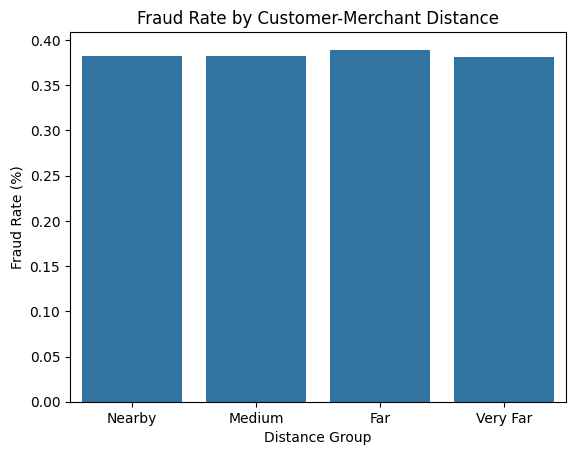

In [188]:
dataset["distance_group"] = pd.cut(
    dataset["distance_km"],
    bins=[0, 25, 50, 100, dataset["distance_km"].max()],
    labels=["Nearby", "Medium", "Far", "Very Far"],
    include_lowest=True
)

distance_fraud_rate = dataset.groupby("distance_group")["is_fraud"].mean() * 100

sns.barplot(
    x=distance_fraud_rate.index,
    y=distance_fraud_rate.values
)

plt.xlabel("Distance Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Customer-Merchant Distance")
plt.show()

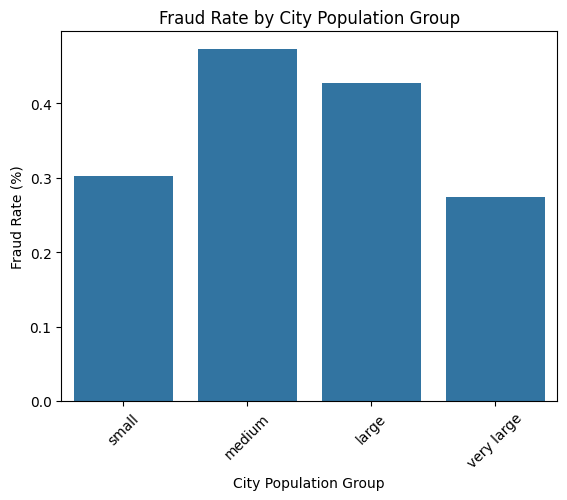

In [189]:
citygrp_rate = dataset.groupby("city_pop_group")["is_fraud"].mean() * 100

sns.barplot(
    x=citygrp_rate.index,
    y=citygrp_rate.values
)

plt.xlabel("City Population Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by City Population Group")
plt.xticks(rotation=45)
plt.show()

In [191]:
import os

os.makedirs("../data/processed", exist_ok=True)

dataset.to_csv("../data/processed/cleaned_fraud_data.csv", index=False)

In [192]:
dataset.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud',
       'day_of_week', 'date', 'day', 'month', 'hour', 'minute', 'year',
       'weekend', 'night', 'age', 'age_group', 'log_amt', 'amount_group',
       'city_pop_group', 'distance_km', 'distance_group'],
      dtype='str')

In [193]:
os.path.exists("../data/processed/cleaned_fraud_data.csv")

True